# King County Housing Data — Exploratory Data Analysis

**Purpose:** Understand the structure, distributions, and relationships across all four core datasets before modelling.

| Dataset | File | Rows | Cols |
|---------|------|------|------|
| Real Property Sales | `EXTR_RPSale.csv` | 2,415,964 | 24 |
| Residential Building | `EXTR_ResBldg.csv` | 532,072 | 50 |
| Parcel | `EXTR_Parcel.csv` | 627,512 | 81 |
| Lookup (code dictionary) | `EXTR_LookUp.csv` | 1,224 | 3 |

**Sections**
1. Load & basic QC
2. Sales — price trends, arms-length filtering
3. Residential Building — structural features
4. Parcel — land & location features
5. Lookup — decode key categorical codes
6. Merged analysis — joined dataset & correlations
7. Feature engineering preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

ENC = 'latin-1'
fmt_k  = mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
fmt_m  = mticker.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
fmt_dol = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')

---
## 1. Load & Basic QC

In [2]:
rp  = pd.read_csv('kc_assessor_data/RealPropertySales/EXTR_RPSale.csv',   low_memory=False, encoding=ENC)
rb  = pd.read_csv('kc_assessor_data/ResidentialBuilding/EXTR_ResBldg.csv', low_memory=False, encoding=ENC)
par = pd.read_csv('kc_assessor_data/Parcel/EXTR_Parcel.csv',               low_memory=False, encoding=ENC)
lu  = pd.read_csv('kc_assessor_data/Lookup/EXTR_LookUp.csv',               low_memory=False, encoding=ENC)

for name, df in [('RPSale', rp), ('ResBldg', rb), ('Parcel', par), ('LookUp', lu)]:
    null_pct = df.isnull().mean().mean() * 100
    print(f'{name:10s}  {df.shape[0]:>10,} rows  x {df.shape[1]:>3} cols  |  avg null rate: {null_pct:.1f}%')

RPSale       2,415,964 rows  x  24 cols  |  avg null rate: 0.0%
ResBldg        532,072 rows  x  50 cols  |  avg null rate: 0.2%


Parcel         627,512 rows  x  81 cols  |  avg null rate: 2.6%
LookUp           1,224 rows  x   3 cols  |  avg null rate: 0.0%


In [3]:
# --- Build PIN (10-char parcel ID) used as the join key across all tables ---
def make_pin(df):
    return df['Major'].astype(str).str.zfill(6) + df['Minor'].astype(str).str.zfill(4)

rp['PIN']  = make_pin(rp)
rb['PIN']  = make_pin(rb)
par['PIN'] = make_pin(par)

print(f"Unique PINs — RPSale:  {rp['PIN'].nunique():>10,}")
print(f"Unique PINs — ResBldg: {rb['PIN'].nunique():>10,}")
print(f"Unique PINs — Parcel:  {par['PIN'].nunique():>10,}")

# Parse dates
rp['DocumentDate'] = pd.to_datetime(rp['DocumentDate'], errors='coerce')
rp['SaleYear']     = rp['DocumentDate'].dt.year
rp['SaleMonth']    = rp['DocumentDate'].dt.month

Unique PINs — RPSale:     713,763
Unique PINs — ResBldg:    524,216
Unique PINs — Parcel:     627,512


---
## 2. Real Property Sales
### 2a. Arms-length filtering
`SaleReason=1` (no exclusion flag) + positive price = open-market transaction.

In [4]:
al = rp[
    (rp['SaleReason'] == 1) &
    (rp['SalePrice'] > 10_000) &
    (rp['PropertyClass'] == 8) &       # Res-Improved (SFR)
    (rp['SaleYear'].between(1990, 2024))
].copy()

print(f'All RPSale records:        {len(rp):>10,}')
print(f'Arms-length SFR (1990+):   {len(al):>10,}  ({len(al)/len(rp)*100:.1f}%)')
print(f'\nPrice stats (arms-length SFR):')
al['SalePrice'].describe(percentiles=[.1,.25,.5,.75,.9,.99]).apply(lambda x: f'${x:,.0f}')

All RPSale records:         2,415,964
Arms-length SFR (1990+):      881,057  (36.5%)

Price stats (arms-length SFR):


count       $881,057
mean        $541,982
std         $816,024
min          $10,029
10%         $147,000
25%         $224,494
50%         $374,900
75%         $640,000
90%       $1,000,000
99%       $2,799,922
max      $68,775,000
Name: SalePrice, dtype: str

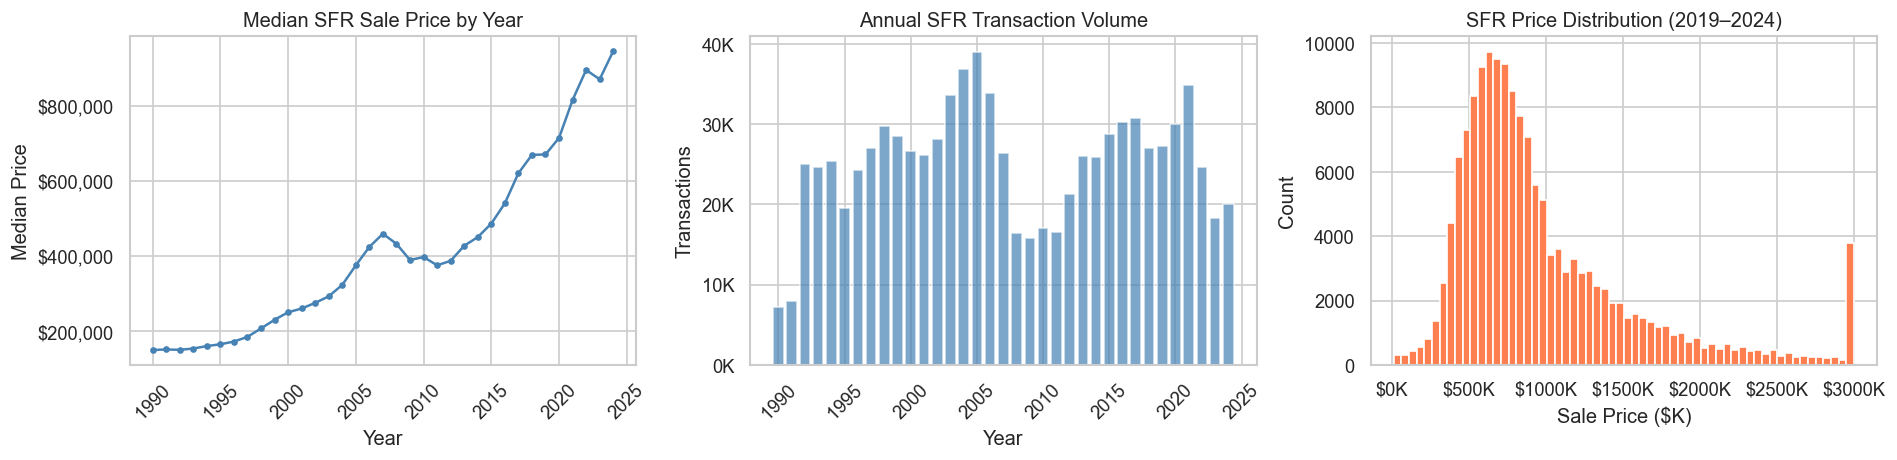

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Annual median sale price
yr_med = al.groupby('SaleYear')['SalePrice'].median()
axes[0].plot(yr_med.index, yr_med.values, marker='o', markersize=3, lw=1.5, color='steelblue')
axes[0].yaxis.set_major_formatter(fmt_dol)
axes[0].set_title('Median SFR Sale Price by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Price')
axes[0].tick_params(axis='x', rotation=45)

# Annual volume
yr_vol = al.groupby('SaleYear').size()
axes[1].bar(yr_vol.index, yr_vol.values, color='steelblue', alpha=0.7)
axes[1].yaxis.set_major_formatter(fmt_k)
axes[1].set_title('Annual SFR Transaction Volume')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=45)

# Price distribution (recent 5 years)
recent = al[al['SaleYear'] >= 2019]['SalePrice'].clip(upper=3_000_000)
axes[2].hist(recent / 1_000, bins=60, color='coral', edgecolor='white')
axes[2].set_title('SFR Price Distribution (2019–2024)')
axes[2].set_xlabel('Sale Price ($K)')
axes[2].set_ylabel('Count')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.tight_layout()
plt.show()

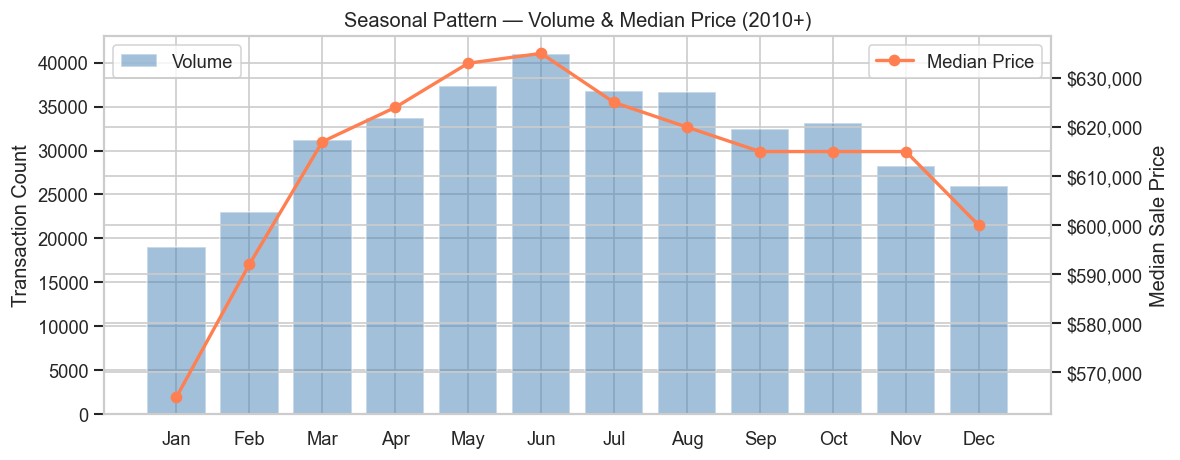

In [6]:
# Seasonal pattern
month_med = al[al['SaleYear'] >= 2010].groupby('SaleMonth')['SalePrice'].median()
month_vol = al[al['SaleYear'] >= 2010].groupby('SaleMonth').size()
mnames = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(mnames, month_vol.values, color='steelblue', alpha=0.5, label='Volume')
ax2.plot(mnames, month_med.values, color='coral', marker='o', lw=2, label='Median Price')
ax1.set_title('Seasonal Pattern — Volume & Median Price (2010+)')
ax1.set_ylabel('Transaction Count')
ax2.set_ylabel('Median Sale Price')
ax2.yaxis.set_major_formatter(fmt_dol)
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 2b. SaleReason breakdown — how much is non-market?

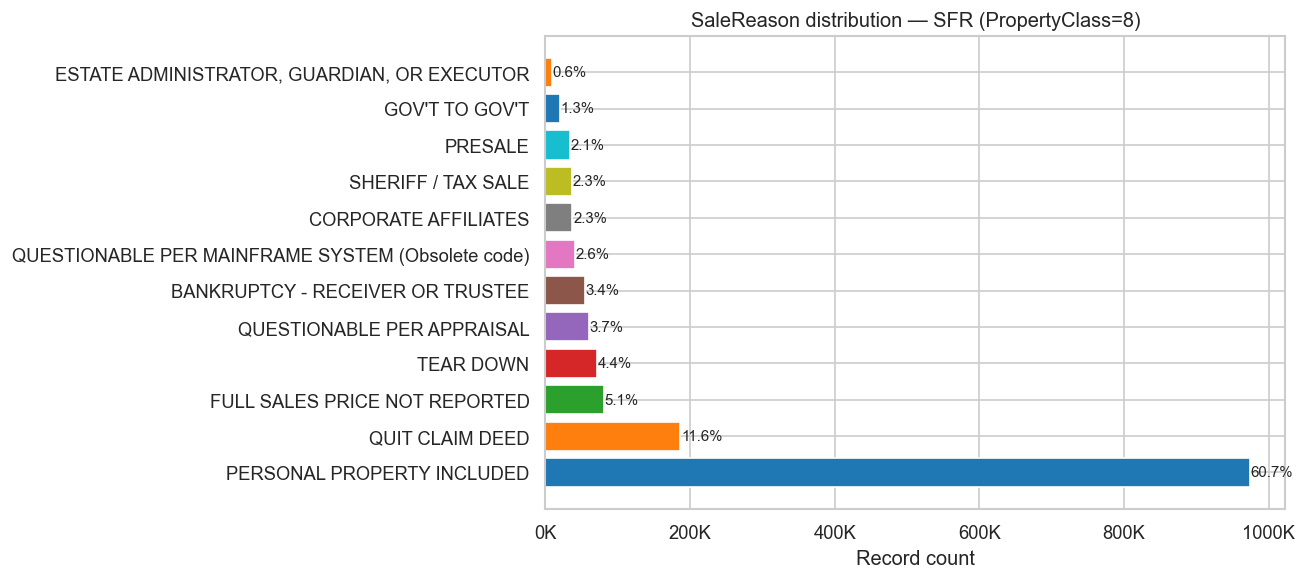

In [7]:
lu7 = lu[lu['LUType'] == 7].set_index('LUItem')['LUDescription'].str.strip()

sr_sfr = rp[rp['PropertyClass'] == 8]['SaleReason'].value_counts().head(12).reset_index()
sr_sfr.columns = ['SaleReason', 'Count']
sr_sfr['Description'] = sr_sfr['SaleReason'].map(lu7).fillna('(code 1 — no exclusion / arms-length)')
sr_sfr['Pct'] = sr_sfr['Count'] / sr_sfr['Count'].sum() * 100

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(sr_sfr['Description'], sr_sfr['Count'], color=sns.color_palette('tab10', len(sr_sfr)))
ax.set_title('SaleReason distribution — SFR (PropertyClass=8)')
ax.set_xlabel('Record count')
ax.xaxis.set_major_formatter(fmt_k)
for bar, pct in zip(bars, sr_sfr['Pct']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Residential Building
### 3a. Key numeric features

ResBldg total: 532,072   |   SFR-filtered: 515,615


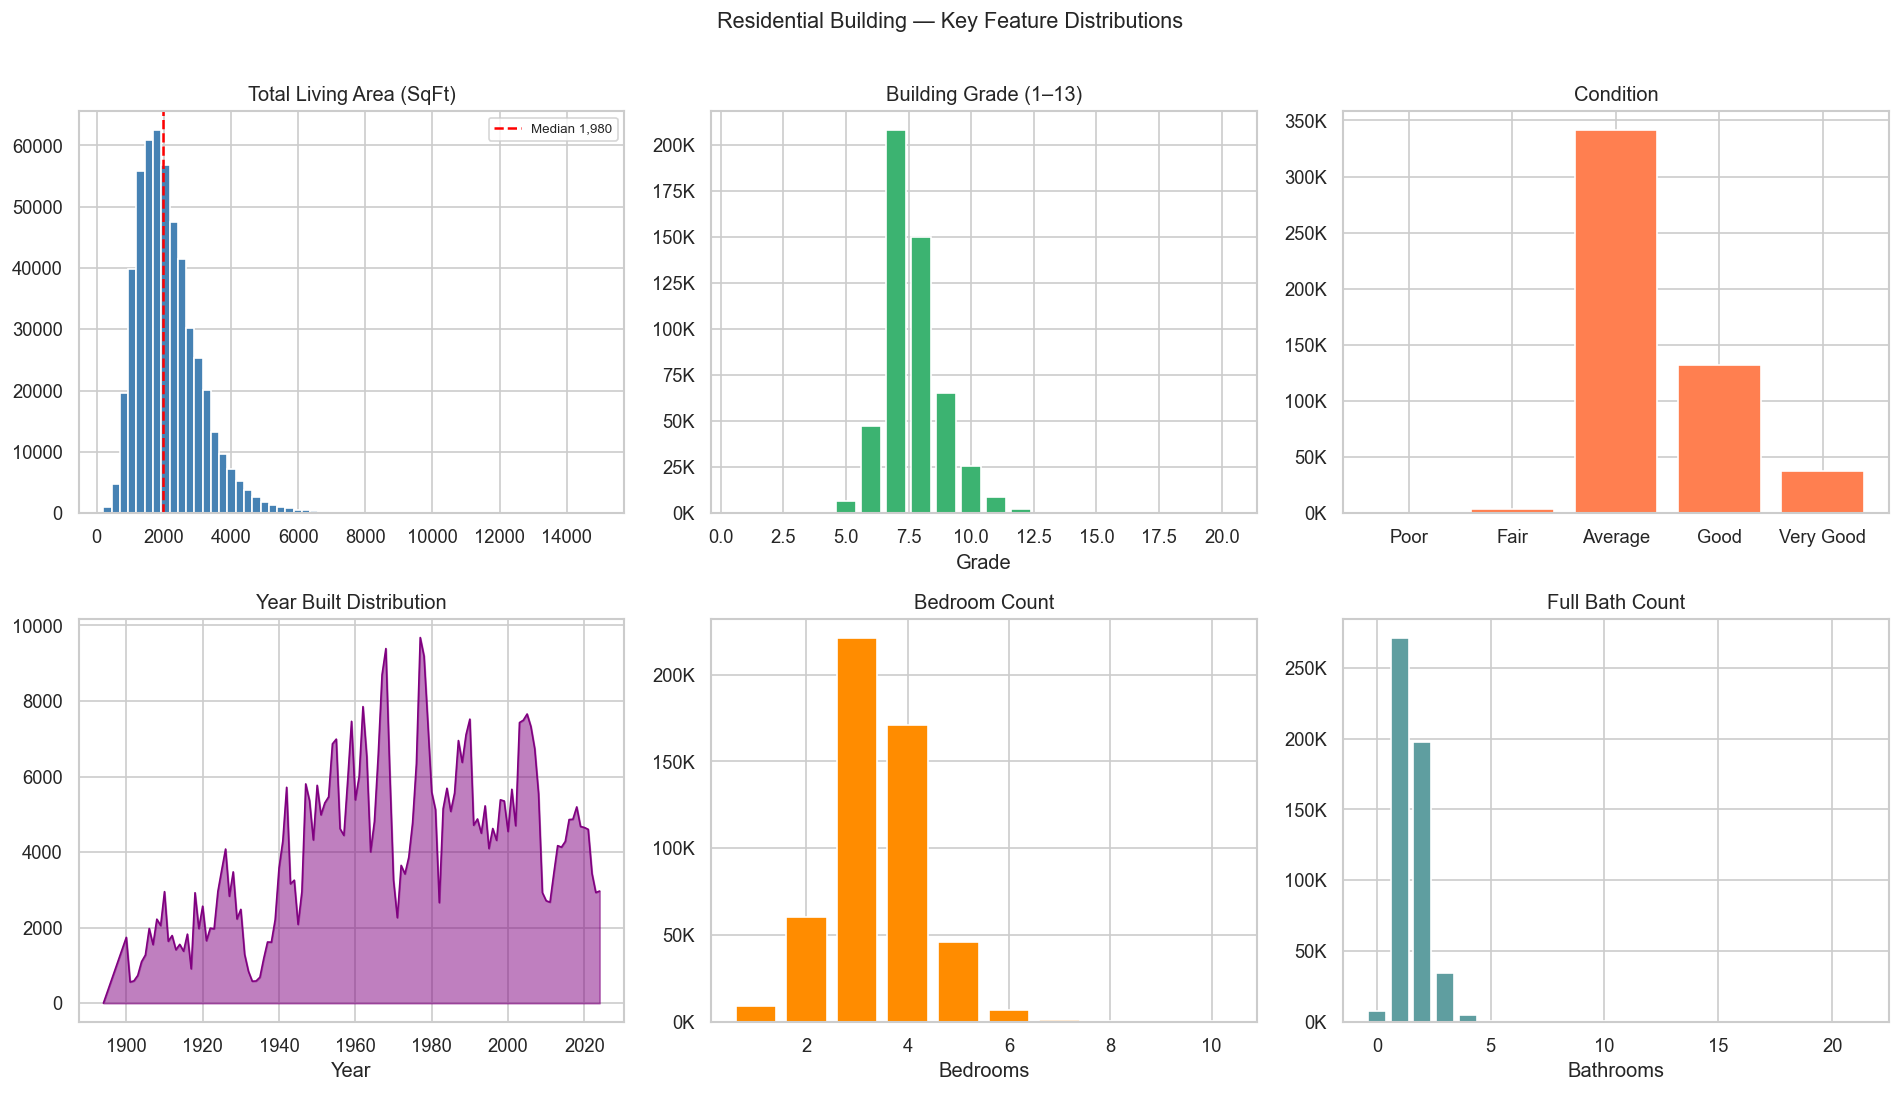

In [8]:
# Filter to plausible single-family buildings
rb_sfr = rb[
    (rb['NbrLivingUnits'] == 1) &
    (rb['SqFtTotLiving'].between(200, 15_000)) &
    (rb['YrBuilt'].between(1870, 2024)) &
    (rb['Bedrooms'].between(1, 10))
].copy()

print(f'ResBldg total: {len(rb):,}   |   SFR-filtered: {len(rb_sfr):,}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Living area
axes[0,0].hist(rb_sfr['SqFtTotLiving'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Total Living Area (SqFt)')
axes[0,0].axvline(rb_sfr['SqFtTotLiving'].median(), color='red', lw=1.5, ls='--', label=f'Median {rb_sfr["SqFtTotLiving"].median():,.0f}')
axes[0,0].legend(fontsize=8)

# BldgGrade
grade_counts = rb_sfr['BldgGrade'].value_counts().sort_index()
axes[0,1].bar(grade_counts.index, grade_counts.values, color='mediumseagreen')
axes[0,1].set_title('Building Grade (1–13)')
axes[0,1].set_xlabel('Grade')
axes[0,1].yaxis.set_major_formatter(fmt_k)

# Condition
cond_counts = rb_sfr['Condition'].value_counts().sort_index()
cond_labels = {1:'Poor',2:'Fair',3:'Average',4:'Good',5:'Very Good'}
axes[0,2].bar(
    [cond_labels.get(i, str(i)) for i in cond_counts.index],
    cond_counts.values, color='coral'
)
axes[0,2].set_title('Condition')
axes[0,2].yaxis.set_major_formatter(fmt_k)

# Year built
yr_counts = rb_sfr['YrBuilt'].value_counts().sort_index()
axes[1,0].fill_between(yr_counts.index, yr_counts.values, alpha=0.5, color='purple')
axes[1,0].plot(yr_counts.index, yr_counts.values, color='purple', lw=1)
axes[1,0].set_title('Year Built Distribution')
axes[1,0].set_xlabel('Year')

# Bedrooms
bed_counts = rb_sfr['Bedrooms'].value_counts().sort_index()
axes[1,1].bar(bed_counts.index, bed_counts.values, color='darkorange')
axes[1,1].set_title('Bedroom Count')
axes[1,1].set_xlabel('Bedrooms')
axes[1,1].yaxis.set_major_formatter(fmt_k)

# Full baths
bath_counts = rb_sfr['BathFullCount'].value_counts().sort_index()
axes[1,2].bar(bath_counts.index, bath_counts.values, color='cadetblue')
axes[1,2].set_title('Full Bath Count')
axes[1,2].set_xlabel('Bathrooms')
axes[1,2].yaxis.set_major_formatter(fmt_k)

plt.suptitle('Residential Building — Key Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

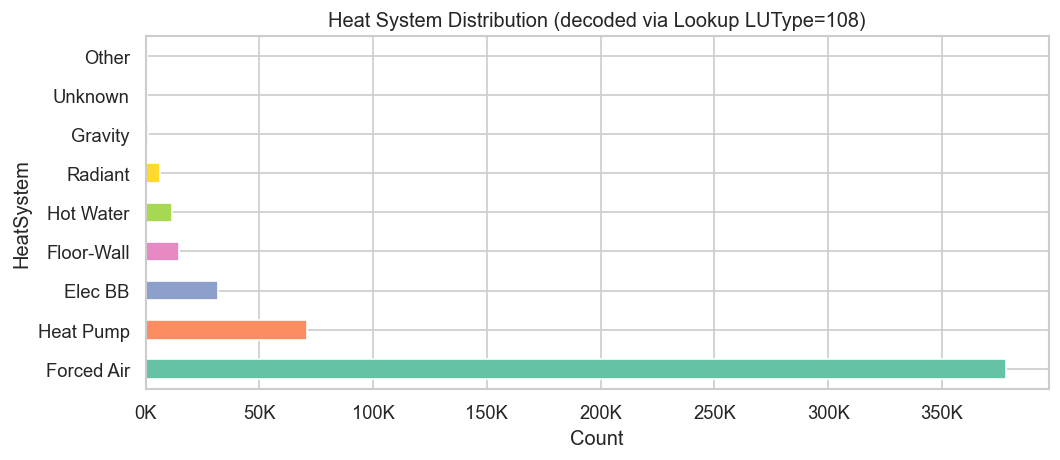

In [9]:
# Heat system decoded via Lookup
lu108 = lu[lu['LUType'] == 108].set_index('LUItem')['LUDescription'].str.strip()
heat_counts = rb_sfr['HeatSystem'].map(lu108).fillna('Unknown').value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
heat_counts.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(heat_counts)))
ax.set_title('Heat System Distribution (decoded via Lookup LUType=108)')
ax.set_xlabel('Count')
ax.xaxis.set_major_formatter(fmt_k)
plt.tight_layout()
plt.show()

---
## 4. Parcel — Land & Location Features

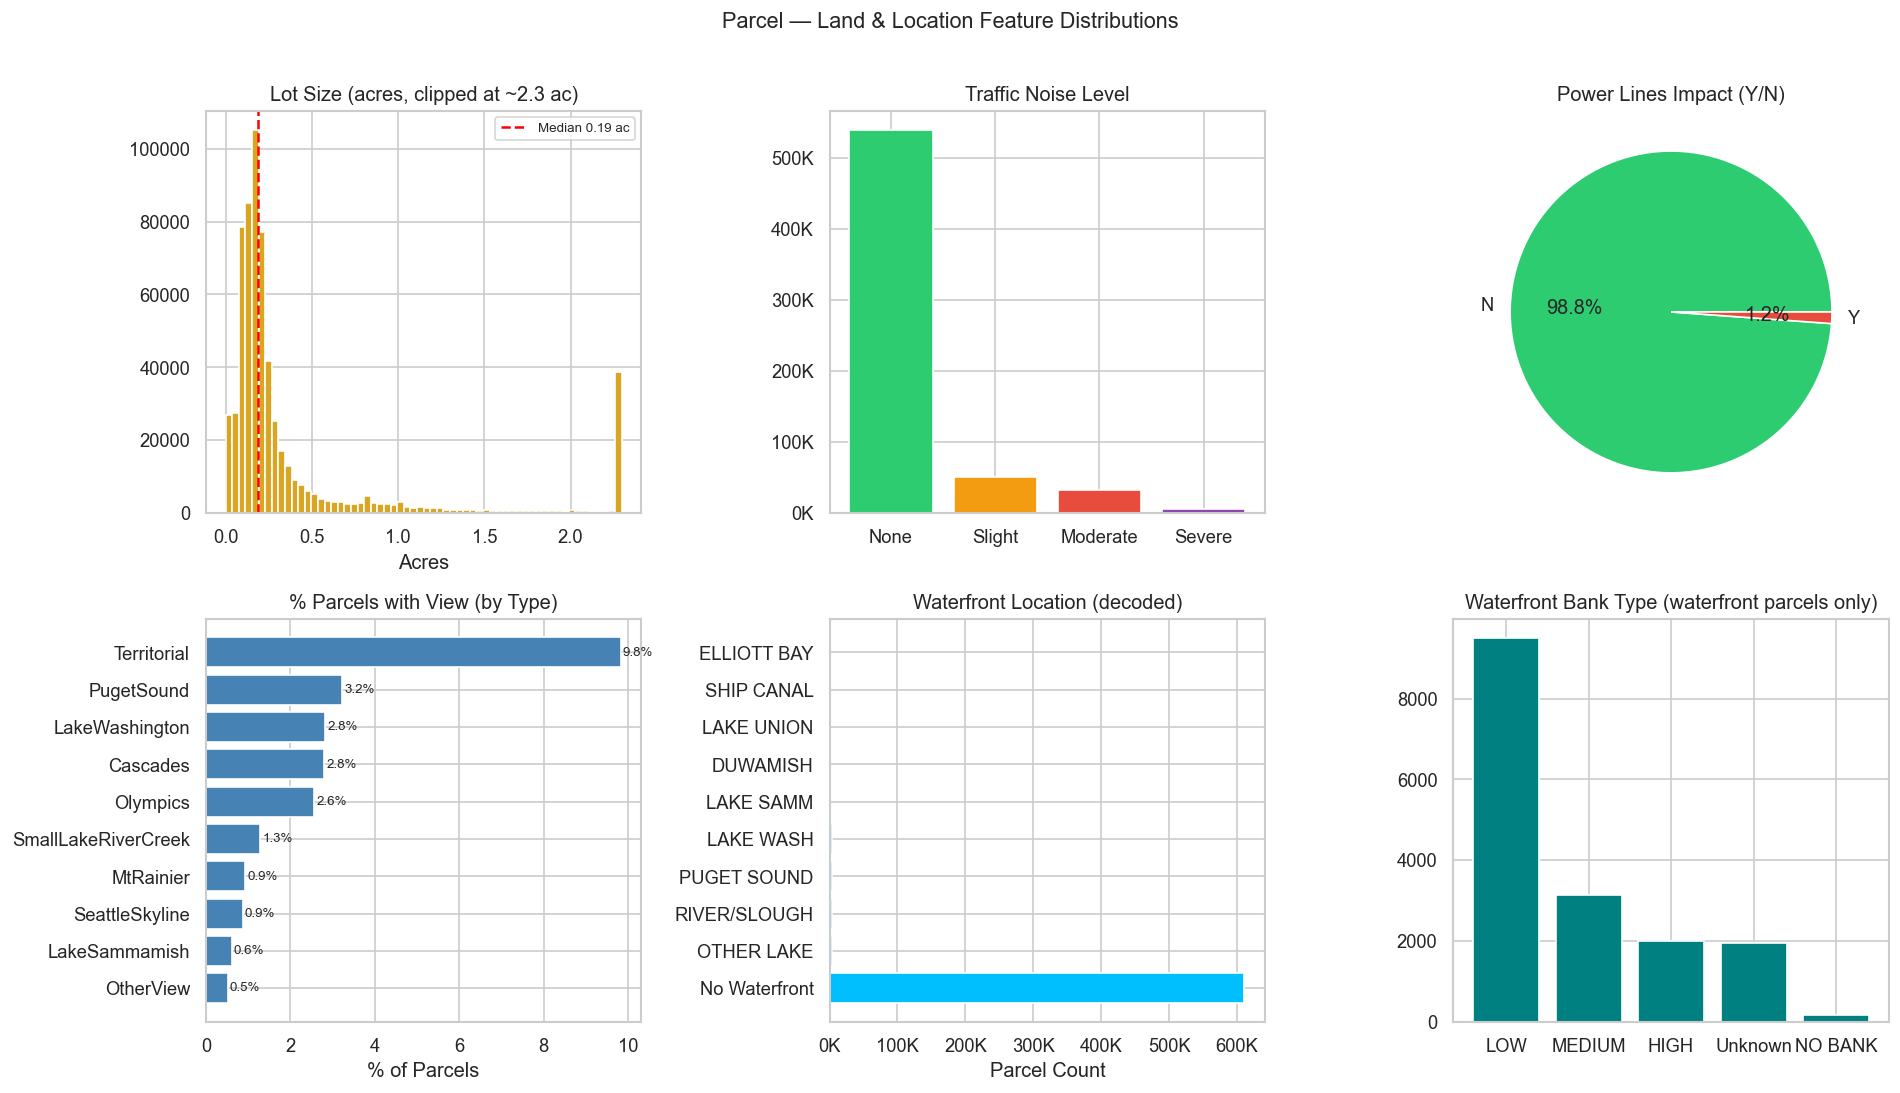

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Lot size
lot = par['SqFtLot'].clip(upper=100_000)
axes[0,0].hist(lot[lot > 0] / 43_560, bins=60, color='goldenrod', edgecolor='white')  # acres
axes[0,0].set_title('Lot Size (acres, clipped at ~2.3 ac)')
axes[0,0].set_xlabel('Acres')
axes[0,0].axvline((lot[lot>0]/43560).median(), color='red', lw=1.5, ls='--',
                   label=f'Median {(lot[lot>0]/43560).median():.2f} ac')
axes[0,0].legend(fontsize=8)

# Traffic Noise
tn_labels = {0:'None',1:'Slight',2:'Moderate',3:'Severe'}
tn_counts = par['TrafficNoise'].map(tn_labels).value_counts()
axes[0,1].bar(tn_counts.index, tn_counts.values, color=['#2ecc71','#f39c12','#e74c3c','#8e44ad'])
axes[0,1].set_title('Traffic Noise Level')
axes[0,1].yaxis.set_major_formatter(fmt_k)

# Power Lines
pl = par['PowerLines'].value_counts()
axes[0,2].pie(pl, labels=pl.index, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0,2].set_title('Power Lines Impact (Y/N)')

# View columns — % of parcels with non-zero value
view_cols = ['MtRainier','Olympics','Cascades','Territorial','SeattleSkyline',
             'PugetSound','LakeWashington','LakeSammamish','SmallLakeRiverCreek','OtherView']
view_pct = {c: (par[c] > 0).mean() * 100 for c in view_cols}
vdf = pd.Series(view_pct).sort_values(ascending=True)
axes[1,0].barh(vdf.index, vdf.values, color='steelblue')
axes[1,0].set_title('% Parcels with View (by Type)')
axes[1,0].set_xlabel('% of Parcels')
for i, (val, name) in enumerate(zip(vdf.values, vdf.index)):
    axes[1,0].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=8)

# Waterfront location decoded
lu50 = lu[lu['LUType'] == 50].set_index('LUItem')['LUDescription'].str.strip()
wf = par['WfntLocation'].map(lu50).fillna('No Waterfront')
wf_counts = wf.value_counts()
axes[1,1].barh(wf_counts.index, wf_counts.values, color='deepskyblue')
axes[1,1].set_title('Waterfront Location (decoded)')
axes[1,1].set_xlabel('Parcel Count')
axes[1,1].xaxis.set_major_formatter(fmt_k)

# WfntBank decoded
lu52 = lu[lu['LUType'] == 52].set_index('LUItem')['LUDescription'].str.strip()
wfb = par[par['WfntLocation'] > 0]['WfntBank'].map(lu52).fillna('Unknown')
wfb_counts = wfb.value_counts()
axes[1,2].bar(wfb_counts.index, wfb_counts.values, color='teal')
axes[1,2].set_title('Waterfront Bank Type (waterfront parcels only)')

plt.suptitle('Parcel — Land & Location Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Merged Analysis
Join recent arms-length SFR sales with building and parcel attributes.

In [11]:
# Use latest sale per PIN (avoid double-counting re-sales)
al_sorted = al.sort_values('DocumentDate')
al_latest = al_sorted.drop_duplicates('PIN', keep='last')

# One building record per PIN (take primary building)
rb_primary = rb_sfr.sort_values('BldgNbr').drop_duplicates('PIN', keep='first')

# One parcel record per PIN
par_unique = par.drop_duplicates('PIN', keep='first')

merged = (
    al_latest
    .merge(rb_primary[['PIN','SqFtTotLiving','BldgGrade','Condition',
                        'YrBuilt','YrRenovated','Bedrooms','BathFullCount',
                        'BathHalfCount','Bath3qtrCount','HeatSystem','ViewUtilization']],
           on='PIN', how='inner')
    .merge(par_unique[['PIN','SqFtLot','TrafficNoise','PowerLines','WfntLocation',
                        'WfntFootage','Territorial','PugetSound','LakeWashington',
                        'Olympics','Cascades','SeattleSkyline']],
           on='PIN', how='left')
)

print(f'Merged dataset: {len(merged):,} rows')
print(f'Sale year range: {merged["SaleYear"].min()} – {merged["SaleYear"].max()}')
merged[['SalePrice','SqFtTotLiving','BldgGrade','Condition',
        'YrBuilt','Bedrooms','BathFullCount','SqFtLot']].describe()

Merged dataset: 409,586 rows
Sale year range: 1990 – 2024


,SalePrice,SqFtTotLiving,BldgGrade,Condition,YrBuilt,Bedrooms,BathFullCount,SqFtLot
count,"409,586.00","409,586.00","409,586.00","409,586.00","409,586.00","409,586.00","409,586.00","409,586.00"
mean,"658,131.16","2,197.59",7.74,3.43,"1,974.98",3.46,1.59,"16,270.21"
std,"660,238.75",966.25,1.16,0.65,30.32,0.91,0.70,"56,762.52"
min,"10,029.00",220.00,2.00,1.00,"1,894.00",1.00,0.00,375.00
25%,"297,000.00","1,510.00",7.00,3.00,"1,954.00",3.00,1.00,"5,175.00"
50%,"500,000.00","2,030.00",8.00,3.00,"1,978.00",3.00,2.00,"7,672.00"
75%,"800,000.00","2,690.00",8.00,4.00,"2,001.00",4.00,2.00,"10,779.00"
max,"60,000,000.00","14,140.00",20.00,5.00,"2,024.00",10.00,21.00,"7,039,596.00"


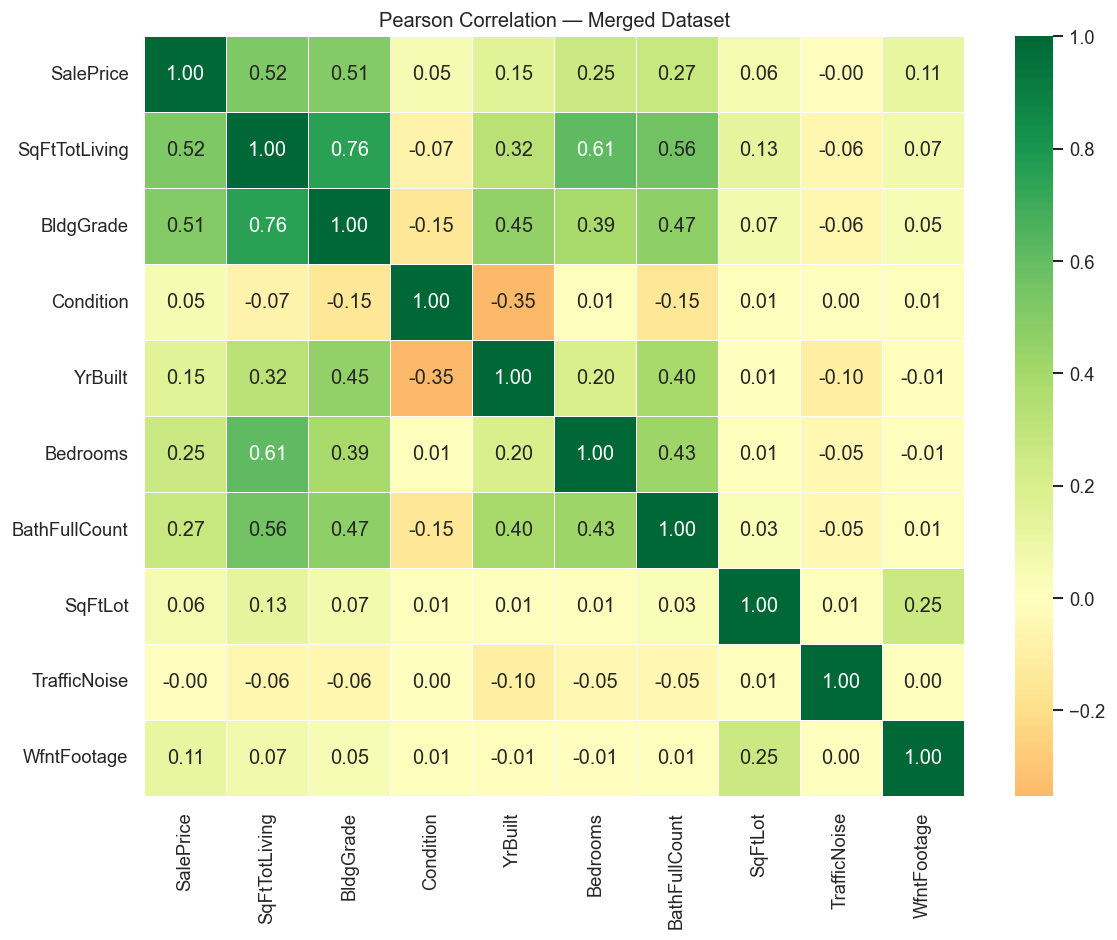

In [12]:
# Correlation heatmap on numeric features
num_cols = ['SalePrice','SqFtTotLiving','BldgGrade','Condition',
            'YrBuilt','Bedrooms','BathFullCount','SqFtLot',
            'TrafficNoise','WfntFootage']
corr = merged[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation — Merged Dataset')
plt.tight_layout()
plt.show()

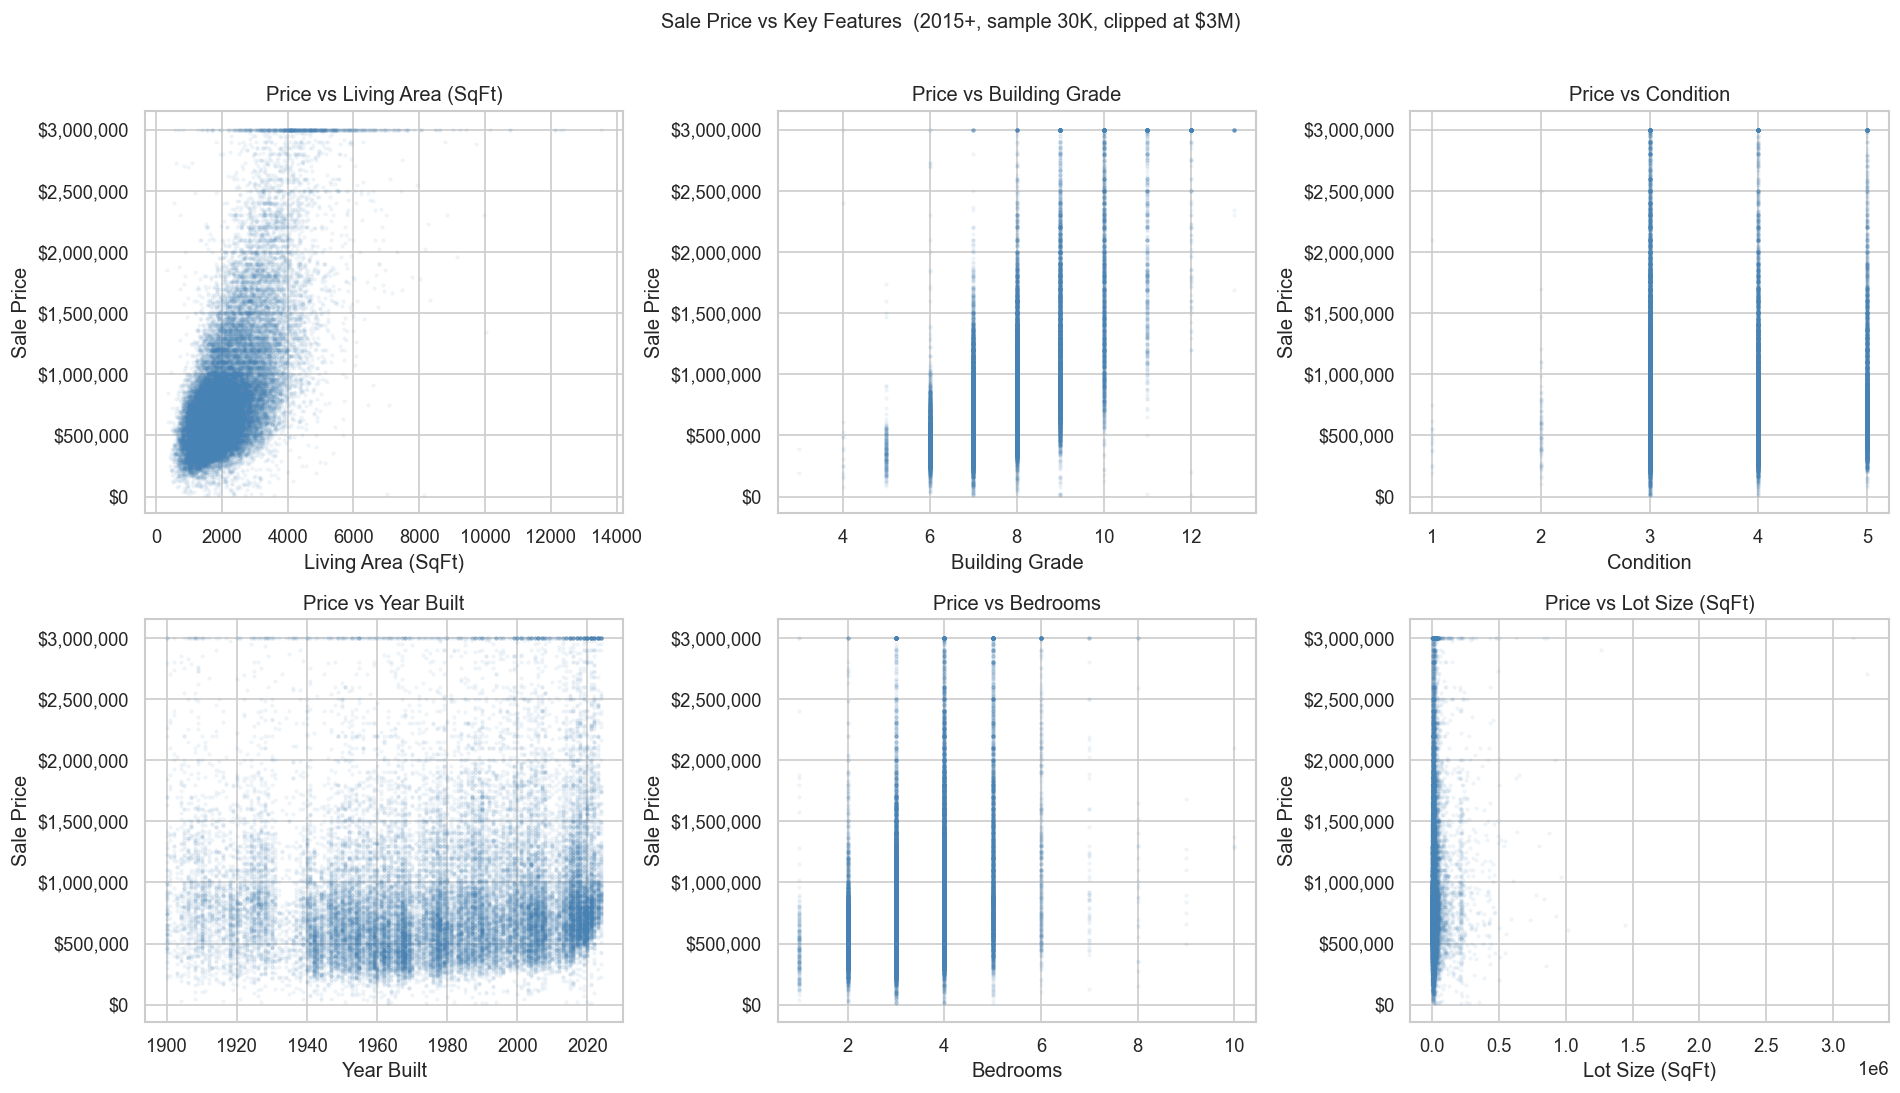

In [13]:
# Price vs key continuous predictors
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_pairs = [
    ('SqFtTotLiving', 'Living Area (SqFt)'),
    ('BldgGrade',     'Building Grade'),
    ('Condition',     'Condition'),
    ('YrBuilt',       'Year Built'),
    ('Bedrooms',      'Bedrooms'),
    ('SqFtLot',       'Lot Size (SqFt)'),
]
sample = merged[merged['SaleYear'] >= 2015].sample(min(30_000, len(merged)), random_state=42)
price_clip = sample['SalePrice'].clip(upper=3_000_000)

for ax, (col, label) in zip(axes.flat, plot_pairs):
    ax.scatter(sample[col], price_clip, alpha=0.05, s=3, color='steelblue', rasterized=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Sale Price')
    ax.yaxis.set_major_formatter(fmt_dol)
    ax.set_title(f'Price vs {label}')

plt.suptitle('Sale Price vs Key Features  (2015+, sample 30K, clipped at $3M)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

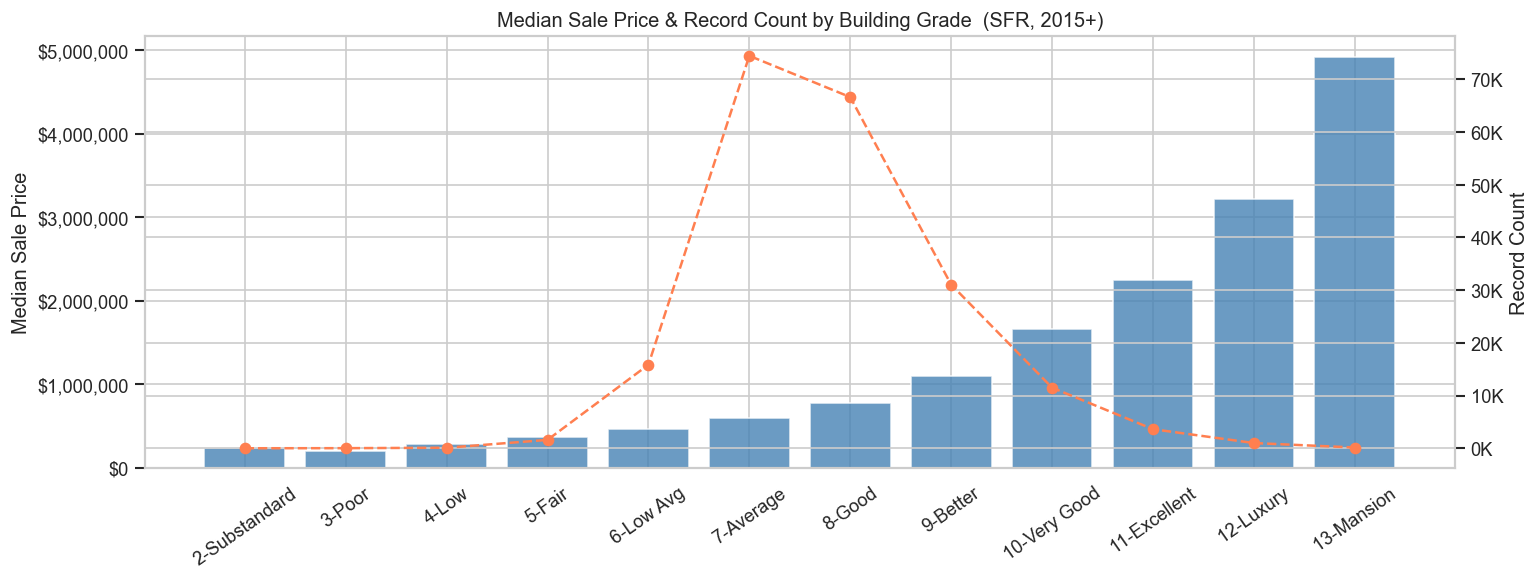

In [14]:
# Median price by BldgGrade
grade_price = merged[merged['SaleYear'] >= 2015].groupby('BldgGrade')['SalePrice'].agg(['median','count'])
grade_labels = {
    1:'1-Cabin',2:'2-Substandard',3:'3-Poor',4:'4-Low',5:'5-Fair',
    6:'6-Low Avg',7:'7-Average',8:'8-Good',9:'9-Better',
    10:'10-Very Good',11:'11-Excellent',12:'12-Luxury',13:'13-Mansion'
}
grade_price.index = [grade_labels.get(i, str(i)) for i in grade_price.index]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
bars = ax1.bar(grade_price.index, grade_price['median'], color='steelblue', alpha=0.8)
ax2.plot(grade_price.index, grade_price['count'], 'o--', color='coral', lw=1.5)
ax1.set_title('Median Sale Price & Record Count by Building Grade  (SFR, 2015+)')
ax1.set_ylabel('Median Sale Price')
ax2.set_ylabel('Record Count')
ax1.yaxis.set_major_formatter(fmt_dol)
ax2.yaxis.set_major_formatter(fmt_k)
ax1.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

Median SFR price (waterfront):     $1,300,000
Median SFR price (non-waterfront): $734,950
Waterfront premium:                +76.9%


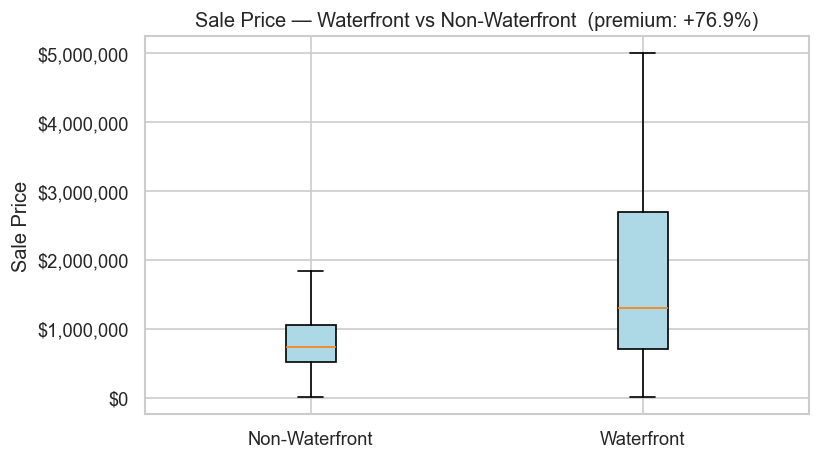

In [15]:
# Waterfront premium
wf_flag = (merged['WfntLocation'] > 0)
recent = merged[merged['SaleYear'] >= 2015]
wf_med  = recent[recent['WfntLocation'] > 0]['SalePrice'].median()
nwf_med = recent[recent['WfntLocation'] == 0]['SalePrice'].median()
premium = (wf_med / nwf_med - 1) * 100
print(f'Median SFR price (waterfront):     ${wf_med:,.0f}')
print(f'Median SFR price (non-waterfront): ${nwf_med:,.0f}')
print(f'Waterfront premium:                {premium:+.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
data = [recent[recent['WfntLocation'] == 0]['SalePrice'].clip(upper=5_000_000),
        recent[recent['WfntLocation'] >  0]['SalePrice'].clip(upper=5_000_000)]
ax.boxplot(data, labels=['Non-Waterfront', 'Waterfront'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'), showfliers=False)
ax.set_title(f'Sale Price — Waterfront vs Non-Waterfront  (premium: {premium:+.1f}%)')
ax.set_ylabel('Sale Price')
ax.yaxis.set_major_formatter(fmt_dol)
plt.tight_layout()
plt.show()

Median price by traffic noise level:
             median   count
None     739,950.00  176983
Slight   740,000.00   17082
Moderate 715,000.00   10203
Severe   719,000.00    1702


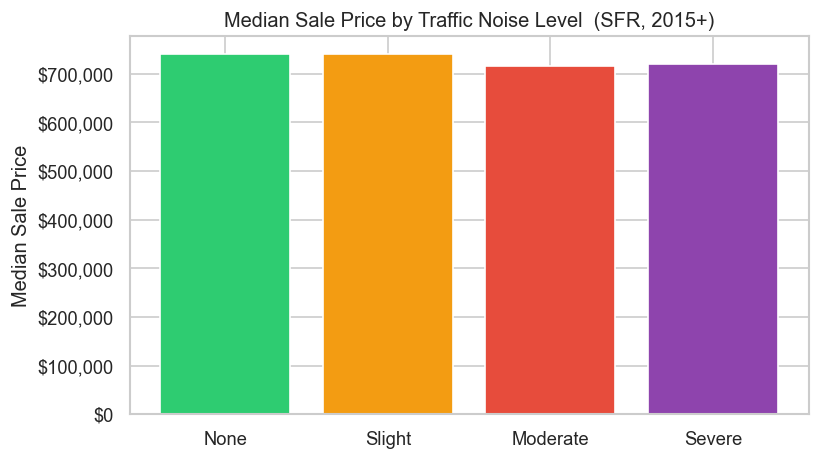

In [16]:
# Traffic noise penalty
recent_tn = merged[merged['SaleYear'] >= 2015]
tn_price = recent_tn.groupby('TrafficNoise')['SalePrice'].agg(['median','count'])
tn_price.index = ['None','Slight','Moderate','Severe']
print('Median price by traffic noise level:')
print(tn_price)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tn_price.index, tn_price['median'],
       color=['#2ecc71','#f39c12','#e74c3c','#8e44ad'])
ax.set_title('Median Sale Price by Traffic Noise Level  (SFR, 2015+)')
ax.set_ylabel('Median Sale Price')
ax.yaxis.set_major_formatter(fmt_dol)
plt.tight_layout()
plt.show()

---
## 6. Feature Engineering Preview
Key derived variables needed for modelling.

In [17]:
fe = merged.copy()

# EffectiveAge: years since built or last renovated
fe['LastSignificantYear'] = fe.apply(
    lambda r: r['YrRenovated'] if r['YrRenovated'] > 0 else r['YrBuilt'], axis=1
)
fe['EffectiveAge'] = fe['SaleYear'] - fe['LastSignificantYear']
fe['EffectiveAge'] = fe['EffectiveAge'].clip(lower=0)

# PricePerSqFt
fe['PricePerSqFt'] = fe['SalePrice'] / fe['SqFtTotLiving'].replace(0, np.nan)

# Total bathrooms (weighted)
fe['TotalBaths'] = fe['BathFullCount'] + 0.75 * fe['Bath3qtrCount'] + 0.5 * fe['BathHalfCount']

# Any view flag
fe['HasView'] = (
    fe[['Territorial','PugetSound','LakeWashington','Olympics','Cascades','SeattleSkyline']]
    .gt(0).any(axis=1).astype(int)
)

# Waterfront flag
fe['IsWaterfront'] = (fe['WfntLocation'] > 0).astype(int)

# ViewUtilization as binary
fe['HasViewUtilization'] = fe['ViewUtilization'].str.strip().str.upper().eq('Y').astype(int)

fe_sample = fe[fe['SaleYear'] >= 2015][
    ['SalePrice','PricePerSqFt','SqFtTotLiving','EffectiveAge',
     'BldgGrade','TotalBaths','HasView','IsWaterfront']
].describe(percentiles=[.25,.5,.75])
fe_sample

,SalePrice,PricePerSqFt,SqFtTotLiving,EffectiveAge,BldgGrade,TotalBaths,HasView,IsWaterfront
count,"205,970.00","205,970.00","205,970.00","205,970.00","205,970.00","205,970.00","205,970.00","205,970.00"
mean,"921,600.98",419.18,"2,233.48",37.67,7.80,2.32,0.11,0.02
std,"773,969.38",236.62,991.23,30.50,1.16,0.81,0.31,0.13
min,"10,091.00",1.47,220.00,0.00,2.00,0.00,0.00,0.00
25%,"528,000.00",273.50,"1,510.00",11.00,7.00,1.75,0.00,0.00
50%,"737,331.50",380.93,"2,050.00",33.00,8.00,2.50,0.00,0.00
75%,"1,065,000.00",524.19,"2,760.00",59.00,8.00,2.75,0.00,0.00
max,"60,000,000.00","10,733.70","14,140.00",124.00,13.00,21.00,1.00,1.00


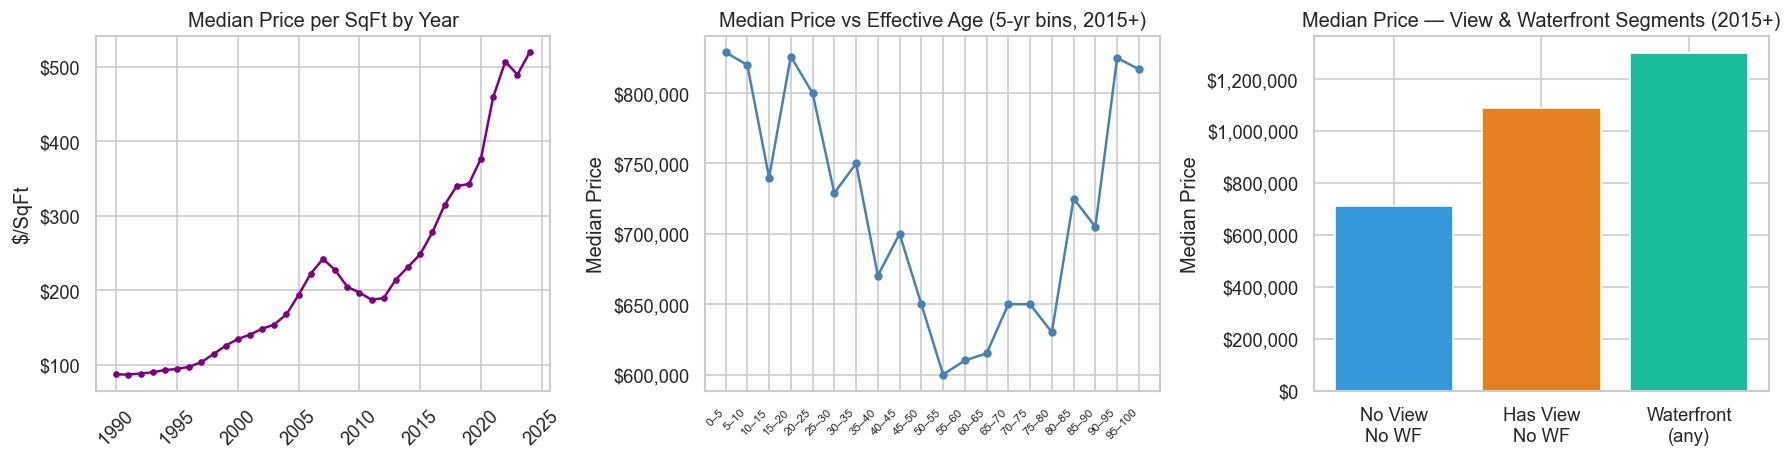

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Price per SqFt over time
ppsf_yr = fe[fe['PricePerSqFt'].between(50, 2000)].groupby('SaleYear')['PricePerSqFt'].median()
axes[0].plot(ppsf_yr.index, ppsf_yr.values, marker='o', markersize=3, color='purple', lw=1.5)
axes[0].set_title('Median Price per SqFt by Year')
axes[0].set_ylabel('$/SqFt')
axes[0].yaxis.set_major_formatter(fmt_dol)
axes[0].tick_params(axis='x', rotation=45)

# EffectiveAge vs Price
age_recent = fe[(fe['SaleYear'] >= 2015) & fe['EffectiveAge'].between(0, 100)]
age_bins = pd.cut(age_recent['EffectiveAge'], bins=range(0, 105, 5))
age_price = age_recent.groupby(age_bins)['SalePrice'].median()
age_price.index = [f'{int(i.left)}–{int(i.right)}' for i in age_price.index]
axes[1].plot(range(len(age_price)), age_price.values, marker='o', markersize=4, color='steelblue')
axes[1].set_xticks(range(len(age_price)))
axes[1].set_xticklabels(age_price.index, rotation=45, ha='right', fontsize=7)
axes[1].set_title('Median Price vs Effective Age (5-yr bins, 2015+)')
axes[1].set_ylabel('Median Price')
axes[1].yaxis.set_major_formatter(fmt_dol)

# View & waterfront premium
fe_r = fe[fe['SaleYear'] >= 2015]
cats = {
    'No View\nNo WF':    fe_r[(fe_r['HasView']==0) & (fe_r['IsWaterfront']==0)]['SalePrice'].median(),
    'Has View\nNo WF':   fe_r[(fe_r['HasView']==1) & (fe_r['IsWaterfront']==0)]['SalePrice'].median(),
    'Waterfront\n(any)': fe_r[fe_r['IsWaterfront']==1]['SalePrice'].median(),
}
axes[2].bar(cats.keys(), cats.values(), color=['#3498db','#e67e22','#1abc9c'])
axes[2].set_title('Median Price — View & Waterfront Segments (2015+)')
axes[2].set_ylabel('Median Price')
axes[2].yaxis.set_major_formatter(fmt_dol)

plt.tight_layout()
plt.show()

---
## 7. EDA Summary

| Topic | Finding |
|-------|---------|
| Arms-length filter | `SaleReason=1` + `PropertyClass=8` + `SalePrice>10K` keeps ~59% of records |
| Price trend | Median SFR price rose sharply 2012–2018, dipped 2018–2019, surged 2020–2022 |
| Seasonality | Peak volume Apr–Aug; prices slightly higher in spring/summer |
| Living area | Median 1,990 sqft; strong positive correlation with price |
| BldgGrade | Grade=7 (Average) dominates 40.7%; grade is a strong price predictor |
| YrRenovated | 94.9% = 0 → must use `EffectiveAge = SaleYear − max(YrBuilt, YrRenovated)` |
| Waterfront | ~2.2% of parcels; significant price premium |
| View | Parcel has 10 binary view columns; `ViewUtilization` (Y/N) is in ResBldg |
| Traffic noise | Negative price signal; 8% of parcels have moderate/severe noise |
| Lookup joins | LUType=7→SaleWarning, LUType=108→HeatSystem, LUType=50→WfntLocation body |